## Setup: Import libraries and configure environment

We'll use pandas for CSV data, numpy for arrays, and matplotlib for plotting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


## Environment configuration for MPI
Set the OpenMPI shared-memory transport backend to avoid issues with large process counts.


In [ ]:
%env OMPI_MCA_btl_vader_single_copy_mechanism=none
%env OMP_NUM_THREADS=1


env: OMPI_MCA_btl_vader_single_copy_mechanism=none


In [ ]:
!chmod +x ../NDP_helper_scripts/

In [ ]:
tandem_exc = 'tandem_2d_6p'
mpi_rank = 30
NDP_mpi_cmds = "--mca btl_vader_single_copy_mechanism none --mca btl_vader_backing_directory /tmp --bind-to none"
NDP_mpi_wrapper = "../NDP_helper_scripts/wrapper.sh"

## Run 1: Quasi-Dynamic (QD) mode — the standard approach

This run uses **mode = QD** in the <span style="color:orange">bp3_QD.toml</span>, which solves the fault stress balance quasi-statically at each time step. The solver inverts the elastic operator **K** fresh at each step—no precalculated Green's functions. We limit to 5 steps for demonstration speed. This is the simplest approach but slower because the linear system is solved repeatedly.


In [ ]:
! mpiexec  $NDP_mpi_cmds -n $mpi_rank  $NDP_mpi_wrapper $tandem_exc  bp3_QD.toml --petsc -ts_max_steps 50 -ts_monitor -options_file ../uniform/petsc_config.cfg


               ___          ___         _____         ___          ___
      ___     /  /\        /__/\       /  /::\       /  /\        /__/\
     /  /\   /  /::\       \  \:\     /  /:/\:\     /  /:/_      |  |::\
    /  /:/  /  /:/\:\       \  \:\   /  /:/  \:\   /  /:/ /\     |  |:|:\
   /  /:/  /  /:/~/::\  _____\__\:\ /__/:/ \__\:| /  /:/ /:/_  __|__|:|\:\
  /  /::\ /__/:/ /:/\:\/__/::::::::\\  \:\ /  /://__/:/ /:/ /\/__/::::| \:\
 /__/:/\:\\  \:\/:/__\/\  \:\~~\~~\/ \  \:\  /:/ \  \:\/:/ /:/\  \:\~~\__\/
 \__\/  \:\\  \::/      \  \:\  ~~~   \  \:\/:/   \  \::/ /:/  \  \:\
      \  \:\\  \:\       \  \:\        \  \::/     \  \:\/:/    \  \:\
       \__\/ \  \:\       \  \:\        \__\/       \  \::/      \  \:\
              \__\/        \__\/                     \__\/        \__\/

                     tandem version v1.0-374-g7edf057
                            domain dimension 2
                            polynomial degree 6
                    minimum order of quadrature

## Run 2: QD with Green's function precomputation (QDGreen, part 1)

This run uses **mode = QDGreen**, which precomputes and stores Green’s function operator **G** on the first stage. Subsequent steps reuse **G**, avoiding expensive linear solves. This is significantly faster for long simulations. Here, we will manually stop the run after a few Green’s function calculations for presentation purposes.

The GF are checkpointed to the temp dir by setting in the <span style="color:orange">bp3_QDGreen_1.toml</span>  file

```toml
[gf_checkpoint]
prefix = "temp"
```


In [ ]:
! mpiexec  $NDP_mpi_cmds -n $mpi_rank  $NDP_mpi_wrapper $tandem_exc  bp3_QDGreen_1.toml --petsc -options_file ../uniform/petsc_config.cfg


               ___          ___         _____         ___          ___
      ___     /  /\        /__/\       /  /::\       /  /\        /__/\
     /  /\   /  /::\       \  \:\     /  /:/\:\     /  /:/_      |  |::\
    /  /:/  /  /:/\:\       \  \:\   /  /:/  \:\   /  /:/ /\     |  |:|:\
   /  /:/  /  /:/~/::\  _____\__\:\ /__/:/ \__\:| /  /:/ /:/_  __|__|:|\:\
  /  /::\ /__/:/ /:/\:\/__/::::::::\\  \:\ /  /://__/:/ /:/ /\/__/::::| \:\
 /__/:/\:\\  \:\/:/__\/\  \:\~~\~~\/ \  \:\  /:/ \  \:\/:/ /:/\  \:\~~\__\/
 \__\/  \:\\  \::/      \  \:\  ~~~   \  \:\/:/   \  \::/ /:/  \  \:\
      \  \:\\  \:\       \  \:\        \  \::/     \  \:\/:/    \  \:\
       \__\/ \  \:\       \  \:\        \__\/       \  \::/      \  \:\
              \__\/        \__\/                     \__\/        \__\/

                     tandem version v1.0-374-g7edf057
                            domain dimension 2
                            polynomial degree 6
                    minimum order of quadrature

In [11]:
!du -sh temp/* | sort -h

0	temp/gf_facet_labels.bin.tmp.info
0	temp/gf_mat.bin.tmp.info
4.0K	temp/gf_facet_labels.bin
60M	temp/gf_mat.bin


In [12]:
!rm -r temp

In [ ]:
! ../NDP_helper_scripts/mpi_cleanup.sh

## Run 3: QD with Green's function — checkpoint and resume (QDGreen, part 2)
This second QDGreen run loads precalculated Green’s function from a checkpoint file. We will run it up to 7e9 seconds over the first earthquake cycle. The simulation will be underresolved for running time presentation purposes.

This will be done by setting in <span style="color:orange">bp3_QDGreen_2.toml</span>

```
final_time = 7e9
```
```
[gf_checkpoint]
prefix = "gf_res_0.50"
freq_cputime = 10
```

In [ ]:
! mpiexec  $NDP_mpi_cmds -n $mpi_rank  $NDP_mpi_wrapper $tandem_exc bp3_QDGreen_2.toml --petsc -ts_monitor -options_file ../uniform/petsc_config.cfg


               ___          ___         _____         ___          ___
      ___     /  /\        /__/\       /  /::\       /  /\        /__/\
     /  /\   /  /::\       \  \:\     /  /:/\:\     /  /:/_      |  |::\
    /  /:/  /  /:/\:\       \  \:\   /  /:/  \:\   /  /:/ /\     |  |:|:\
   /  /:/  /  /:/~/::\  _____\__\:\ /__/:/ \__\:| /  /:/ /:/_  __|__|:|\:\
  /  /::\ /__/:/ /:/\:\/__/::::::::\\  \:\ /  /://__/:/ /:/ /\/__/::::| \:\
 /__/:/\:\\  \:\/:/__\/\  \:\~~\~~\/ \  \:\  /:/ \  \:\/:/ /:/\  \:\~~\__\/
 \__\/  \:\\  \::/      \  \:\  ~~~   \  \:\/:/   \  \::/ /:/  \  \:\
      \  \:\\  \:\       \  \:\        \  \::/     \  \:\/:/    \  \:\
       \__\/ \  \:\       \  \:\        \__\/       \  \::/      \  \:\
              \__\/        \__\/                     \__\/        \__\/

                     tandem version v1.0-374-g7edf057
                            domain dimension 2
                            polynomial degree 6
                    minimum order of quadrature

## Analysis: Plot slip-rate evolution at a probe point on the fault

Read the fault probe output (15 km down-dip) and plot the magnitude of slip-rate versus time on a log scale. The time series reveals seismic ruptures (high slip-rate spikes) and low background rates across the simulated ~250-year cycle.


Text(0, 0.5, 'Slip rate (m/s)')

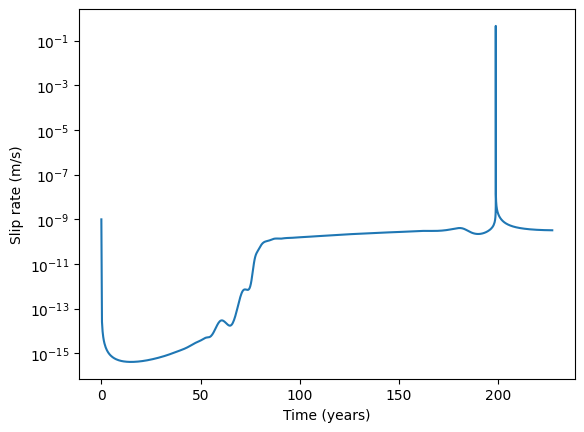

In [19]:
sec_to_years = 356 * 24 * 3600
probe_15km = pd.read_csv('fltst_dp150.csv', comment='#')
plt.plot(probe_15km['Time'] / sec_to_years, np.abs(probe_15km['slip-rate0']), label='15km')
plt.yscale('log')
plt.xlabel('Time (years)')
plt.ylabel('Slip rate (m/s)')